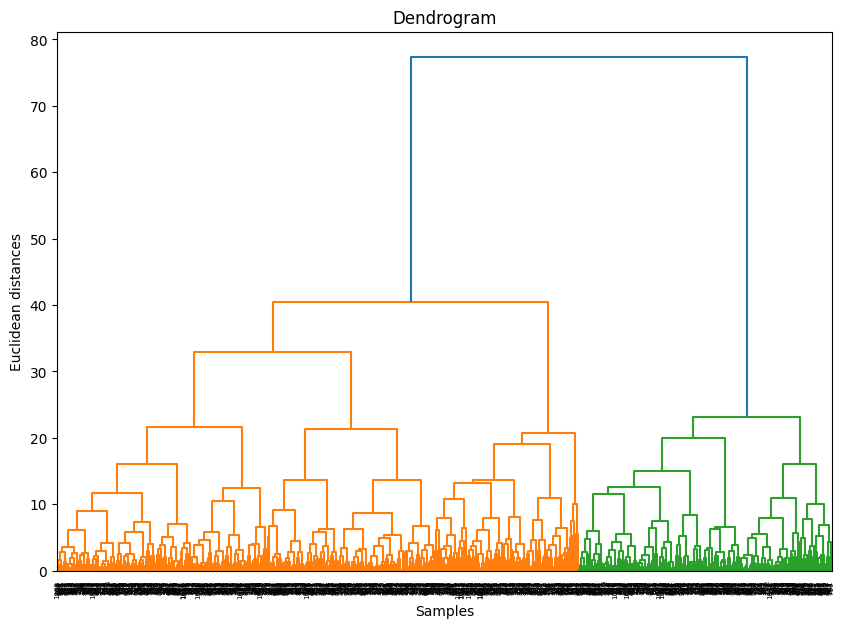

Cluster labels: [0 0 1 ... 1 2 0]
Agglomerative model and scaler saved successfully!


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import joblib

# Load your Excel file
df = pd.read_excel("ALL_with_features.xlsx")  # make sure this file is in the same folder

# Use only numeric columns
X = df.select_dtypes(include=[np.number])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Plot dendrogram
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Euclidean distances')
plt.show()

# Train Agglomerative Clustering
n_clusters = 3  # choose number of clusters based on dendrogram
ahc = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
ahc.fit(X_scaled)

# Cluster labels
labels = ahc.labels_
print("Cluster labels:", labels)

# Add cluster labels to original data and save
df['Cluster'] = labels
df.to_csv('clustered_data.csv', index=False)

# Save model and scaler
joblib.dump(ahc, 'ahc_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Agglomerative model and scaler saved successfully!")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import joblib

# Load your dataset
df = pd.read_excel("ALL_with_features.xlsx")  # make sure this file is in the same folder

# LDA: Text processing
vectorizer = CountVectorizer(stop_words='english')
X_text = vectorizer.fit_transform(df['Item'])  # 'Item' = text column

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda_topics_train = lda.fit_transform(X_text)  # LDA topic distributions for training data

# Agglomerative Clustering
# If you want to cluster the LDA topics
ahc = AgglomerativeClustering(n_clusters=3, linkage='ward')
ahc.fit(lda_topics_train)  # train on LDA topics

# Save everything
joblib.dump(vectorizer, "vectorizer.pkl")
joblib.dump(lda, "lda_model.pkl")
joblib.dump(ahc, "ahc_model.pkl")

# Save the training LDA topics for Flask app nearest-cluster assignment
np.save("train_lda_topics.npy", lda_topics_train)

print("All models and train LDA topics saved successfully!")

All models and train LDA topics saved successfully!
